<a href="https://colab.research.google.com/github/Areca293/Evaluating-the-Isolation-Forest-unsupervised-anomaly-detector-of-onEEGWaveLAD/blob/main/onEEGwaveLAD_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# ==========================================
# Setup & Imports
# ==========================================
!pip install mne isotree

import pathlib as pl
import numpy as np
import mne
import pywt
import pandas as pd
from isotree import IsolationForest
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

print("Libraries imported and Google Drive mounted successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries imported and Google Drive mounted successfully.


In [9]:
# ==========================================
# Dataset Loading
# ==========================================
import pathlib as pl
import mne

def loadDataset(name, subject, montageName, usedChannels, rootPath, montageChannelNames, parametersOfDenoiser=None, verbose=False):
    """
    Loads the EEG dataset according to the pre-defined folder structure.
    Extracts the shifted data version for temporal alignment.
    """
    dataset = pl.Path(name)
    subject = str(subject)
    root = pl.Path(rootPath)

    # Construct the file pathway for raw EEG data files
    pathDataset = pl.Path.joinpath(root, dataset.name + " All Data and Scripts/")
    filenameSubject = pl.Path(subject + "_" + dataset.name + "_" + "shifted.set")
    pathDatasetSubject = pl.Path.joinpath(pathDataset, subject, filenameSubject)

    # Construct the file pathway for the EEG sensor coordinate (Montage) file
    filenameMontage = pl.Path(str("standard-10-5-cap385.elp"))
    montagePath = pl.Path.joinpath(root, dataset.name + " All Data and Scripts/", "EEG_ERP_Processing", filenameMontage)

    # Ingest EEGLAB format files using the MNE framework
    dataForSubject = mne.io.read_raw_eeglab(pathDatasetSubject, preload=True)
    dataForSubject.rename_channels(lambda s: s.strip("."))

    channels = dataForSubject.info["ch_names"]
    sampleFreq = dataForSubject.info["sfreq"]

    if verbose:
        print("Data summary before pre-processing: {}".format(dataForSubject))
        print("Metadata structure before pre-processing: {}".format(dataForSubject.info))

        print("Loading file: " + str(filenameSubject))
        print("Root path: ", root)
        print("Dataset directory: ", pathDataset)
        print("Subject path location: ", pathDatasetSubject)
        print("Montage file path: ", montagePath)
        print("Data successfully loaded for subject: {}".format(subject))
        print("Identified channels: {}".format(channels))

        # Output experimental event markings and stimulus annotations
        print("Annotations data: " + str(dataForSubject.annotations))
        print("Annotation durations shape: " + str(dataForSubject.annotations.duration.shape))
        print("Annotation descriptions shape: " + str(dataForSubject.annotations.description.shape))
        print("Annotation onsets shape: " + str(dataForSubject.annotations.onset.shape))
        if len(dataForSubject.annotations.onset) > 0:
            print("Initial event timestamp: " + str(dataForSubject.annotations.onset[0]))
        print(list(dataForSubject.annotations.description))

        # Render raw EEG signal configurations
        dataForSubject.plot()

    return dataForSubject

In [10]:
# ==========================================
# Step A: EEG Windowing Configuration
# ==========================================
class OnEEGWaveLAD_Windowing:
    def __init__(self, raw_data, RTWL=1000):
        self.raw = raw_data
        self.Sr = raw_data.info['sfreq'] # Sampling frequency (Hz)
        self.RTWL = RTWL                 # Target Real-Time Window Length (ms)

        # Compute the theoretical sample points for the designated window duration
        theoretical_samples = (self.RTWL / 1000.0) * self.Sr

        # Adjust the sample count to the nearest upper power of 2 to optimize wavelet operations
        self.window_samples = int(2 ** np.ceil(np.log2(theoretical_samples)))

        # Derive the actual processing window length in milliseconds
        self.actual_RTWL = (self.window_samples / self.Sr) * 1000.0

        print(f"[Phase A] Target processing window length: {self.RTWL} ms")
        print(f"[Phase A] Adjusted operational window length: {self.actual_RTWL:.2f} ms ({self.window_samples} samples).")

        self.total_samples = raw_data.n_times

    def get_window_stream(self):
        """
        Sequentially partitions the continuous EEG signal into discrete windows.
        Yields segments as a localized data structure simulating real-time streaming blocks.
        """
        for start_idx in range(0, self.total_samples, self.window_samples):
            end_idx = start_idx + self.window_samples
            if end_idx > self.total_samples:
                break

            curr_window, _ = self.raw[:, start_idx:end_idx]

            yield {
                "start_idx": start_idx,
                "end_idx": end_idx,
                "original_window": curr_window,
                "dwt_input": curr_window
            }

## Step B: Multi-level Decomposition
Applies the Pyramidal Sub-band Coding scheme using the Discrete Wavelet Transform (DWT). The EEG window is decomposed into its constituent frequency sub-bands (approximation and detail coefficients) using a specified Mother Wavelet (`MW`).

In [11]:
# ==========================================
# Step B: Multi-level Discrete Wavelet Decomposition
# ==========================================
class OnEEGWaveLAD_DWT:
    def __init__(self, MW='sym4', decomposition_level=None):
        self.MW = MW
        self.level = decomposition_level

    def decompose_window(self, dwt_input_data):
        signal_length = dwt_input_data.shape[1]

        if self.level is None:
            # Determine the maximum mathematically valid decomposition level for the selected mother wavelet
            max_level = pywt.dwt_max_level(signal_length, self.MW)
            # Select the optimal decomposition level constrained by the signal boundary conditions
            actual_level = min(int(np.log2(signal_length)), max_level)
        else:
            actual_level = self.level

        return [pywt.wavedec(dwt_input_data[ch], self.MW, level=actual_level, mode='periodization')
                for ch in range(dwt_input_data.shape[0])]

In [12]:
# =================================================================
# Phases C - G: Multi-scale Anomaly Detection and Signal Reconstruction
# =================================================================
from isotree import IsolationForest
import numpy as np
import pywt

class OnEEGWaveLAD_Denoiser:
    """
    Core Unsupervised Denoising Framework.
    Implements scaleogram formation, anomaly detection via Extended Isolation Forest,
    and adaptive artifact attenuation.
    """
    def __init__(self, n_channels, Bs=20, IFt=100, IFS=512, Ta=0.50, Es=35, el=None):
        # Hyperparameters strictly correspond to the mathematical model established in the thesis:
        # Bs : Buffer Size
        # IFt: Number of trees in Extended Isolation Forest
        # IFS: Isolation Forest Sample Size
        # Ta : Anomaly Score Threshold
        # Es : Expansion Size for structural artifact attenuation
        self.n_channels = n_channels
        self.Bs = Bs
        self.IFt = IFt
        self.IFS = IFS
        self.Ta = Ta
        self.Es = Es
        self.el = el

        # Maintain channel-specific adaptive moving buffers to track temporal baseline history
        self.moving_buffers_history = [[] for _ in range(n_channels)]
        self.models = [None for _ in range(n_channels)]
        self.centroids = [None] * n_channels
        self.max_dists = [None] * n_channels

    def process_window(self, all_channels_coeffs, target_len, MW='sym4', return_debug=False, debug_channel=0):
        denoised_signals = []
        debug_info = {}

        # Number of Instantaneous Spectral Profiles (ISPs) represents the temporal
        # resolution of the scaleogram, derived from half the target length.
        n_isps = target_len // 2

        for ch in range(self.n_channels):
            coeffs = all_channels_coeffs[ch]

            # Separate baseline approximation coefficients (cA) from detail coefficients (cD)
            cA_baseline = coeffs[0]
            details = coeffs[1:]
            num_scales = len(details)

            # [Phase C] Scaleogram Formation: Reshaper & Normalizator
            # Constructs a 2D scaleogram representation from 1D wavelet detail coefficients.
            raw_scaleogram = np.zeros((n_isps, num_scales))
            norm_scaleogram = np.zeros((n_isps, num_scales))

            for i, c in enumerate(details):
                m_level = num_scales - i
                repeats = n_isps // len(c)
                upsampled = np.repeat(c, repeats)

                raw_scaleogram[:, i] = upsampled
                norm_scaleogram[:, i] = upsampled / (2 ** m_level)

            if return_debug and ch == debug_channel:
                debug_info['Step_C_Scaleogram_Raw'] = raw_scaleogram.copy()
                debug_info['Step_C_Scaleogram_Before'] = norm_scaleogram.copy()

            # [Phase E] Artifact Identification: Outlier Scoring via Extended Isolation Forest
            # Evaluates the anomaly score for each ISP in the current analytical window.
            if self.models[ch] is not None:
                scores = self.models[ch].predict(norm_scaleogram)
            else:
                scores = np.zeros(n_isps)

            if return_debug and ch == debug_channel:
                debug_info['Step_E_Scores'] = scores.copy()

            # [Phase D] Channel-Specific Adaptive Moving Buffer Management
            # Updates the historical buffer with the current normalized scaleogram to dynamically
            # adapt to non-stationary shifts in the continuous EEG signal.
            self.moving_buffers_history[ch].append(norm_scaleogram)
            if len(self.moving_buffers_history[ch]) > self.Bs:
                self.moving_buffers_history[ch].pop(0)

            moving_buffer = np.vstack(self.moving_buffers_history[ch])

            if return_debug and ch == debug_channel:
                debug_info['Step_D_Moving_Buffer'] = moving_buffer.copy()

            # Calculate mathematical centroids to measure relative structural deviations
            self.centroids[ch] = np.mean(moving_buffer, axis=0)
            self.max_dists[ch] = np.max(np.abs(moving_buffer - self.centroids[ch]), axis=0) + 1e-8

            # Fit the unsupervised anomaly detection model once the buffer reaches critical capacity
            if moving_buffer.shape[0] >= self.IFS:
                c_dim = moving_buffer.shape[1]
                actual_ndim = c_dim if self.el is None else min(self.el + 1, c_dim)
                self.models[ch] = IsolationForest(ntrees=self.IFt, sample_size=self.IFS, ndim=actual_ndim, random_seed=42)
                self.models[ch].fit(moving_buffer)

            # [Phase F] Artifact Reduction Mitigator via Scale-Specific Attenuation
            # Applies a continuous soft-thresholding mask to attenuate identified anomalous ISPs.
            AT_exp = {idx + e for idx in np.where(scores > self.Ta)[0]
                      for e in range(-self.Es, self.Es + 1) if 0 <= idx + e < n_isps}

            mitigator = np.ones((n_isps, num_scales))

            for idx in AT_exp:
                dist_vec = np.abs(norm_scaleogram[idx] - self.centroids[ch])
                mtga_vec = 1.0 - (dist_vec / self.max_dists[ch])
                mtga_vec = np.clip(mtga_vec, 0.0, 1.0)
                mitigator[idx] = np.minimum(mitigator[idx], mtga_vec)

            if return_debug and ch == debug_channel:
                debug_info['Step_F_Mitigator'] = mitigator.copy()

            # Element-wise multiplication to yield the denoised wavelet structure
            denoised_scaleogram = raw_scaleogram * mitigator

            if return_debug and ch == debug_channel:
                mod_norm_scaleogram = np.zeros_like(denoised_scaleogram)
                for i in range(num_scales):
                    m_level = num_scales - i
                    mod_norm_scaleogram[:, i] = denoised_scaleogram[:, i] / (2 ** m_level)
                debug_info['Step_C_Scaleogram_After'] = mod_norm_scaleogram.copy()

            # [Phase G] Multi-level Composition: Expansor, Reshaper, and iDWT
            # Reconstructs the clean time-domain EEG signal from the processed scaleogram.
            reconstructed_coeffs = [cA_baseline.copy()]

            for i in range(num_scales):
                repeats = n_isps // len(details[i])
                # Expansor module: Restores the attenuated structural row to its original temporal dimension
                expanded_row = denoised_scaleogram[:, i]
                # Reshaper module: Reverses the upsampling process to retrieve the valid discrete detail coefficients
                reshaped_coeffs = expanded_row[::repeats]
                reconstructed_coeffs.append(reshaped_coeffs)

            # Apply Inverse Discrete Wavelet Transform (iDWT) to generate the final denoised block
            denoised_sig = pywt.waverec(reconstructed_coeffs, MW, mode='periodization')
            denoised_signals.append(denoised_sig[:target_len])

        if return_debug:
            return np.array(denoised_signals), debug_info
        return np.array(denoised_signals)

In [13]:
# ==========================================
# Batch Evaluator
# ==========================================
class OnEEGWaveLAD_BatchEvaluator:
    def __init__(self, original, denoised, window_size):
        self.orig = original
        self.denoised = denoised
        self.w_size = window_size
        self.num_windows = self.orig.shape[1] // self.w_size

    def get_metrics(self, channel_idx, thresh=90):
        """
        Computes JSD and SNR parameters for classified target segments (artifacts vs clean).
        """
        orig_ch = self.orig[channel_idx] * 1e6
        denoised_ch = self.denoised[channel_idx] * 1e6
        jsd_tps, jsd_tns, snr_tps, snr_tns = [], [], [], []

        for i in range(self.num_windows):
            start, end = i * self.w_size, (i + 1) * self.w_size
            w_o, w_d = orig_ch[start:end], denoised_ch[start:end]

            # Calculate Jensen-Shannon Divergence metrics
            min_v, max_v = min(np.min(w_o), np.min(w_d)), max(np.max(w_o), np.max(w_d))
            edges = np.linspace(min_v, max_v, 51)
            p, _ = np.histogram(w_o, bins=edges, density=True)
            q, _ = np.histogram(w_d, bins=edges, density=True)
            jsd_val = jensenshannon((p + 1e-10)/np.sum(p+1e-10), (q + 1e-10)/np.sum(q+1e-10)) ** 2

            # Estimate Signal-to-Noise Ratio (SNR) variance parameters
            v_sig, v_noise = np.var(w_d), np.var(w_o - w_d)
            snr_val = float('inf') if v_noise < 1e-10 else 10 * np.log10(v_sig / v_noise)

            # Map validation segments according to magnitude bounds
            if np.max(np.abs(w_o)) > thresh:
                jsd_tps.append(jsd_val)
                snr_tps.append(snr_val)
            else:
                jsd_tns.append(jsd_val)
                snr_tns.append(snr_val)

        f_snr_tps = [v for v in snr_tps if v != float('inf')]
        f_snr_tns = [v for v in snr_tns if v != float('inf')]

        return {
            "Total_Windows": self.num_windows,
            "Blink_Windows_(TPs)": len(jsd_tps),
            "Clean_Windows_(TNs)": len(jsd_tns),
            "Avg_JSD_TPs": np.mean(jsd_tps) if jsd_tps else np.nan,
            "Avg_JSD_TNs": np.mean(jsd_tns) if jsd_tns else np.nan,
            "Avg_SNR_TPs_dB": np.mean(f_snr_tps) if f_snr_tps else np.nan,
            "Avg_SNR_TNs_dB": np.mean(f_snr_tns) if f_snr_tns else 999.99
        }

print("onEEGWaveLAD framework components loaded successfully. System ready for evaluation pipeline.")

onEEGWaveLAD framework components loaded successfully. System ready for evaluation pipeline.


Initiating dataset ingestion and pipeline parameters mapping...
Reading /content/drive/MyDrive/N170 All Data and Scripts/1/1_N170_shifted.fdt
Reading 0 ... 699391  =      0.000 ...   682.999 secs...
Initializing localized processing structures...
[Phase A] Target processing window length: 1000 ms
[Phase A] Adjusted operational window length: 1000.00 ms (1024 samples).
Executing continuous operational monitoring loop on channel: FP1
Structural anomaly instance captured within frame index 1 (t=2s). Saving for profiling analysis.
Required moving buffer evolution time reached. Terminating execution block.


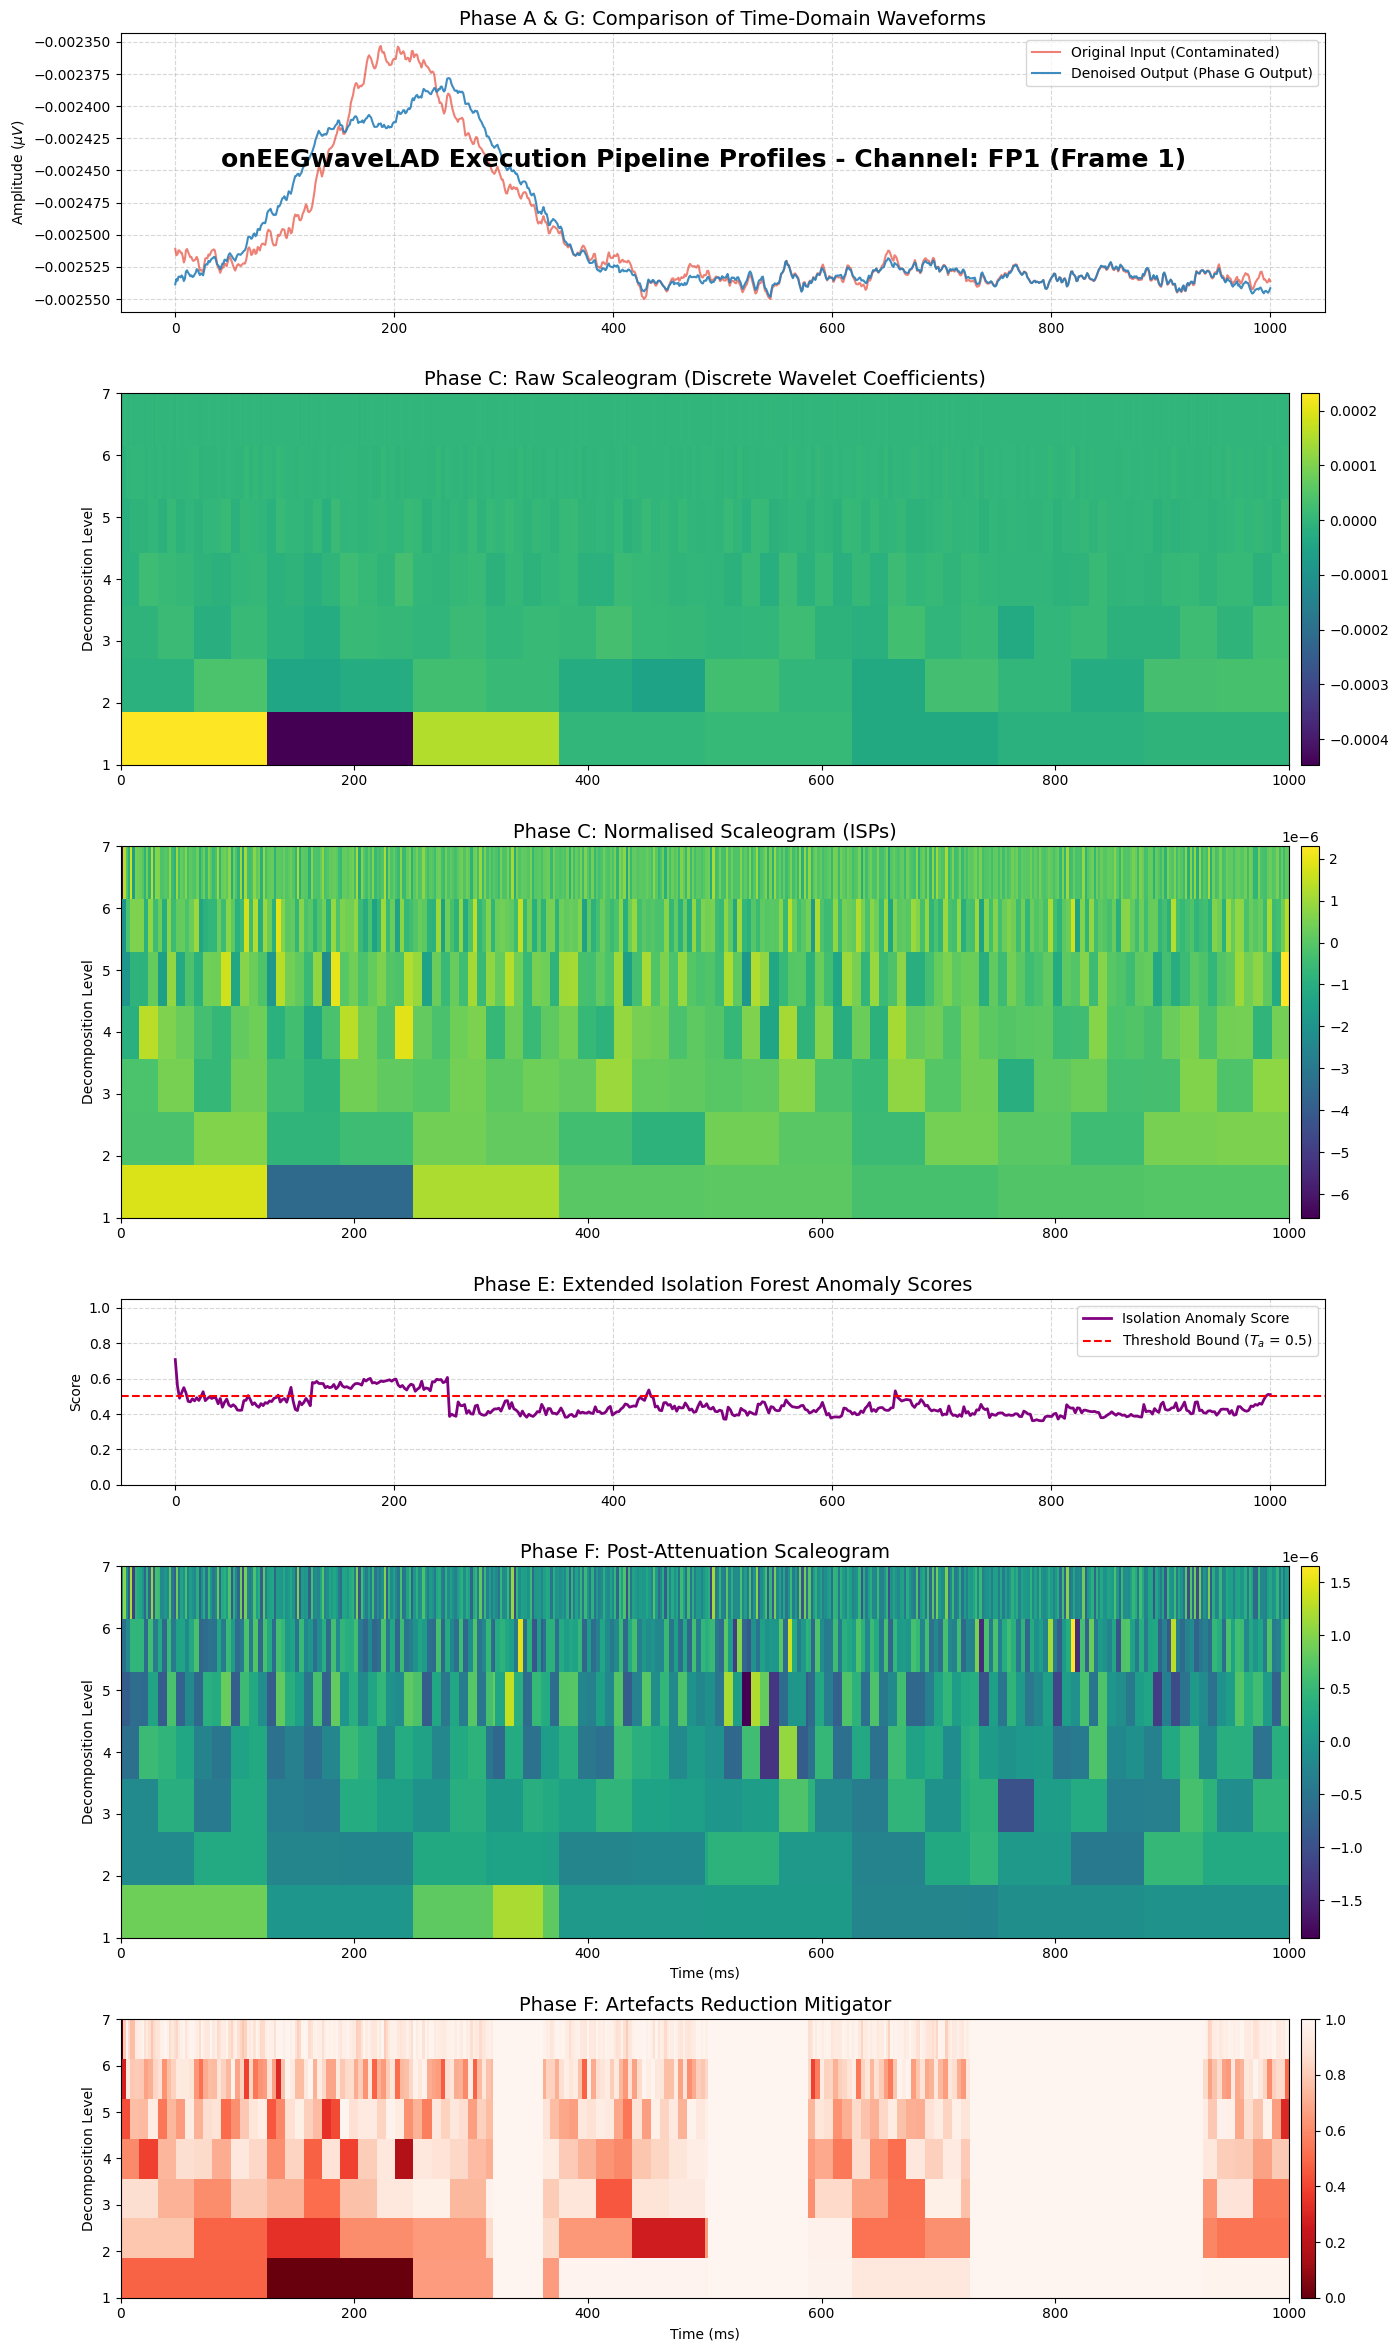

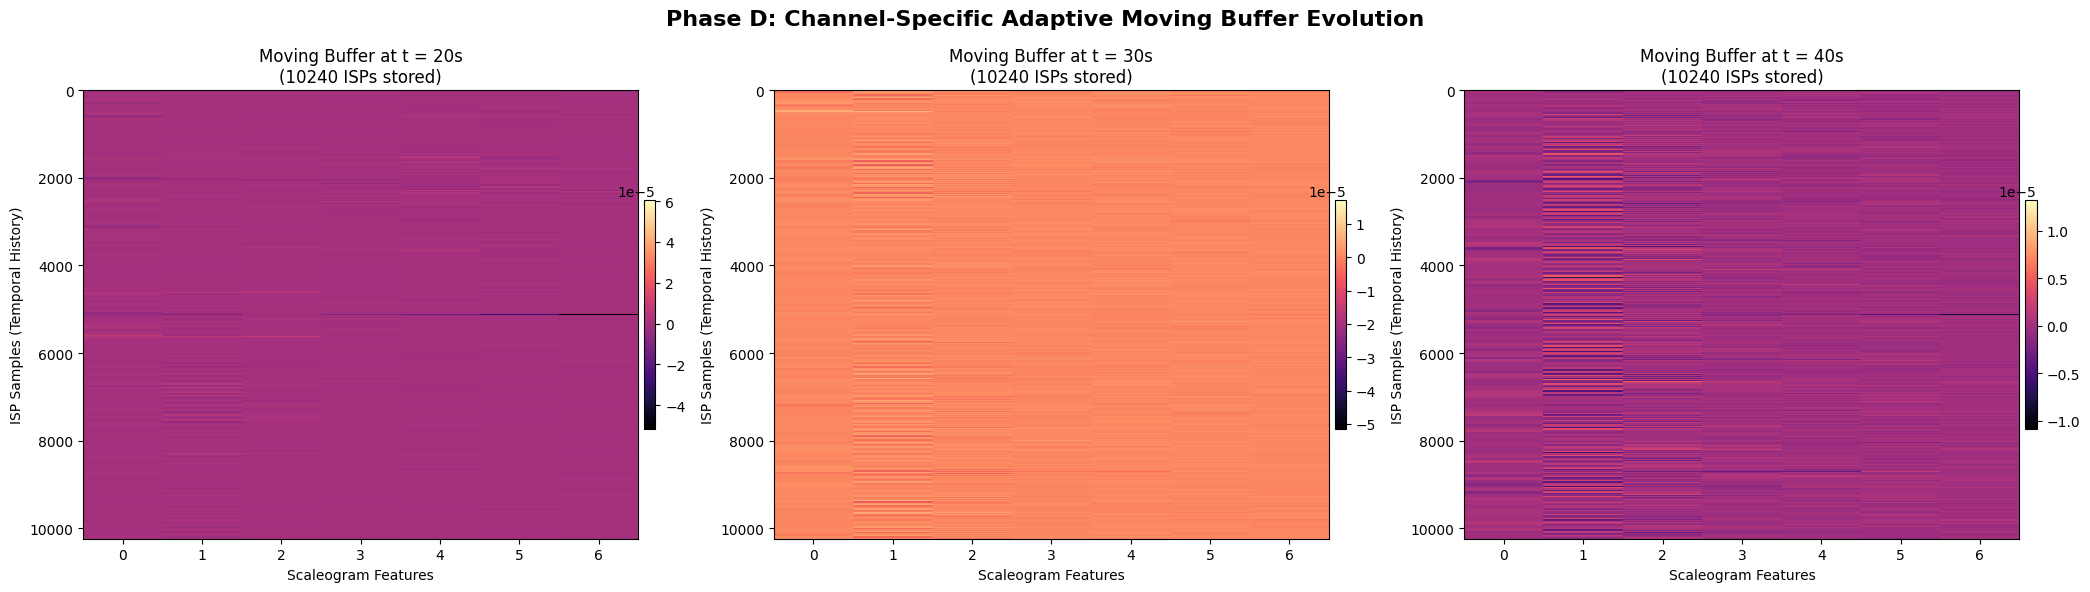

In [14]:
# ==========================================
# 1. Pipeline Configuration & Data Ingestion
# ==========================================
datasetName = "N170"
subject_id = "1"
rootPath = "/content/drive/MyDrive/"

# Configuration mappings for standard channels and montages
montageName = "standard_1020"
usedChannels = ["FP1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","FP2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
montageChannelNames = ["Fp1","F3","F7","FC3","C3","C5","P3","P7","P9","PO7","PO3","O1","Oz","Pz","CPz","Fp2","Fz","F4","F8","FC4","FCz","Cz","C4","C6","P4","P8","P10","PO8","PO4","O2"]
parametersOfDenoiser = None

print("Initiating dataset ingestion and pipeline parameters mapping...")

# Read source files utilizing structural specifications
raw_data = loadDataset(
    name=datasetName,
    subject=subject_id,
    montageName=montageName,
    usedChannels=usedChannels,
    rootPath=rootPath,
    montageChannelNames=montageChannelNames,
    parametersOfDenoiser=parametersOfDenoiser,
    verbose=False
)

# ==========================================
# 2. Framework Component Initialization
# ==========================================
print("Initializing localized processing structures...")
# Phase A: Signal segmentation configuration
windowing = OnEEGWaveLAD_Windowing(raw_data, RTWL=1000)

# Phase B: Wavelet feature transformation mapping
dwt = OnEEGWaveLAD_DWT(MW='sym4')

# Phase C-G: Algorithmic identification and modeling configuration
num_channels = len(raw_data.ch_names)
denoiser = OnEEGWaveLAD_Denoiser(n_channels=num_channels, Bs=20, IFS=512, Ta=0.50, Es=35)

# Isolate ocular signal channel profiles for validation monitoring
target_channel_name = 'Fp1'
if target_channel_name in raw_data.ch_names:
    debug_ch_idx = raw_data.ch_names.index(target_channel_name)
else:
    debug_ch_idx = 0

target_debug_info = None
target_original_sig = None
target_denoised_sig = None
target_window_idx = -1

# Standardized historical storage variables for visualizing the moving buffer evolution
moving_buffer_snapshots = []
moving_buffer_times = []
# Specific timestamps (in seconds) to capture the operational buffer state for dynamic profiling
capture_seconds = [20, 30, 40]

# ==========================================
# 3. Pseudo-Real-Time Data Stream Execution
# ==========================================
print(f"Executing continuous operational monitoring loop on channel: {raw_data.ch_names[debug_ch_idx]}")

for i, win in enumerate(windowing.get_window_stream()):
    # Phase B Execution
    coeffs = dwt.decompose_window(win['dwt_input'])

    # Phase C - G Processing
    denoised_signals, debug = denoiser.process_window(
        all_channels_coeffs=coeffs,
        target_len=win['original_window'].shape[1],
        return_debug=True,
        debug_channel=debug_ch_idx
    )

    current_time_sec = int((i + 1) * windowing.actual_RTWL / 1000.0)
    if current_time_sec in capture_seconds and current_time_sec not in moving_buffer_times:
        moving_buffer_snapshots.append(debug['Step_D_Moving_Buffer'].copy())
        moving_buffer_times.append(current_time_sec)

    scores = debug.get('Step_E_Scores')
    if scores is not None and np.max(scores) > denoiser.Ta and target_debug_info is None:
        target_window_idx = i
        target_debug_info = debug
        target_original_sig = win['original_window'][debug_ch_idx]
        target_denoised_sig = denoised_signals[debug_ch_idx]
        print(f"Structural anomaly instance captured within frame index {i} (t={current_time_sec}s). Saving for profiling analysis.")

    if target_debug_info is not None and current_time_sec >= max(capture_seconds):
        print("Required moving buffer evolution time reached. Terminating execution block.")
        break

# ==========================================
# 4. Statistical Visualization and Diagnostics
# ==========================================
if target_debug_info is not None:
    # ---------------------------------------------------------
    # PART 1: Standard Diagnostics (No Smoothing for Scaleograms)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(6, 1, figsize=(14, 24), gridspec_kw={'height_ratios': [1.5, 2, 2, 1, 2, 1.5]})
    fig.suptitle(f"onEEGwaveLAD Execution Pipeline Profiles - Channel: {raw_data.ch_names[debug_ch_idx]} (Frame {target_window_idx})", fontsize=18, fontweight='bold', y=0.92)

    time_axis = np.linspace(0, windowing.actual_RTWL, len(target_original_sig))
    isp_time_axis = np.linspace(0, windowing.actual_RTWL, len(target_debug_info['Step_E_Scores']))

    # Plot 1: Phase A & G (Temporal waveforms)
    axes[0].plot(time_axis, target_original_sig, label="Original Input (Contaminated)", color='#e74c3c', alpha=0.7, linewidth=1.5)
    axes[0].plot(time_axis, target_denoised_sig, label="Denoised Output (Phase G Output)", color='#2980b9', alpha=0.9, linewidth=1.5)
    axes[0].set_title("Phase A & G: Comparison of Time-Domain Waveforms", fontsize=14)
    axes[0].set_ylabel(r"Amplitude ($\mu V$)")
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # Plot 2: Phase C (Raw Scaleogram - NOT Normalised)
    sc_raw = target_debug_info['Step_C_Scaleogram_Raw'].T
    im1 = axes[1].imshow(sc_raw, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_raw.shape[0]], interpolation='none')
    axes[1].set_title("Phase C: Raw Scaleogram (Discrete Wavelet Coefficients)", fontsize=14)
    axes[1].set_ylabel("Decomposition Level")
    fig.colorbar(im1, ax=axes[1], fraction=0.02, pad=0.01)

    # Plot 3: Phase C (Normalised Scaleogram)
    sc_before = target_debug_info['Step_C_Scaleogram_Before'].T
    im2 = axes[2].imshow(sc_before, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_before.shape[0]], interpolation='none')
    axes[2].set_title("Phase C: Normalised Scaleogram (ISPs)", fontsize=14)
    axes[2].set_ylabel("Decomposition Level")
    fig.colorbar(im2, ax=axes[2], fraction=0.02, pad=0.01)

    # Plot 4: Phase D & E (Mathematical anomaly profiling scores)
    axes[3].plot(isp_time_axis, target_debug_info['Step_E_Scores'], color='purple', linewidth=2, label='Isolation Anomaly Score')
    axes[3].axhline(y=denoiser.Ta, color='red', linestyle='--', label=f'Threshold Bound ($T_a$ = {denoiser.Ta})')
    axes[3].set_title("Phase E: Extended Isolation Forest Anomaly Scores", fontsize=14)
    axes[3].set_ylabel("Score")
    axes[3].set_ylim(0, 1.05)
    axes[3].legend(loc='upper right')
    axes[3].grid(True, linestyle='--', alpha=0.5)

    # Plot 5: Phase F (Post-attenuation structural profiles)
    sc_after = target_debug_info['Step_C_Scaleogram_After'].T
    im4 = axes[4].imshow(sc_after, aspect='auto', cmap='viridis', origin='lower', extent=[0, windowing.actual_RTWL, 1, sc_after.shape[0]], interpolation='none')
    axes[4].set_title("Phase F: Post-Attenuation Scaleogram", fontsize=14)
    axes[4].set_ylabel("Decomposition Level")
    axes[4].set_xlabel("Time (ms)")
    fig.colorbar(im4, ax=axes[4], fraction=0.02, pad=0.01)

    # Plot 6: Phase F (Artefacts Reduction Mitigator)
    mitigator = target_debug_info['Step_F_Mitigator'].T
    im5 = axes[5].imshow(mitigator, aspect='auto', cmap='Reds_r', origin='lower', vmin=0, vmax=1, extent=[0, windowing.actual_RTWL, 1, mitigator.shape[0]], interpolation='none')
    axes[5].set_title("Phase F: Artefacts Reduction Mitigator", fontsize=14)
    axes[5].set_ylabel("Decomposition Level")
    axes[5].set_xlabel("Time (ms)")
    fig.colorbar(im5, ax=axes[5], fraction=0.02, pad=0.01)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # PART 2: Moving Buffer Evolution Visualization
    # ---------------------------------------------------------
    if len(moving_buffer_snapshots) > 0:
        n_snapshots = len(moving_buffer_snapshots)
        fig2, axes2 = plt.subplots(1, n_snapshots, figsize=(7 * n_snapshots, 6))
        fig2.suptitle("Phase D: Channel-Specific Adaptive Moving Buffer Evolution", fontsize=16, fontweight='bold', y=0.98)

        if n_snapshots == 1:
            axes2 = [axes2]

        for idx, (moving_buffer_data, t) in enumerate(zip(moving_buffer_snapshots, moving_buffer_times)):
            im_buf = axes2[idx].imshow(moving_buffer_data, aspect='auto', cmap='magma', interpolation='none')
            axes2[idx].set_title(f"Moving Buffer at t = {t}s\n({moving_buffer_data.shape[0]} ISPs stored)", fontsize=12)
            axes2[idx].set_ylabel("ISP Samples (Temporal History)")
            axes2[idx].set_xlabel("Scaleogram Features")
            fig2.colorbar(im_buf, ax=axes2[idx], fraction=0.02, pad=0.01)

        plt.tight_layout()
        plt.show()

else:
    print("The processing sample buffer requires continuous loading frames, or standard target parameters did not shift past the threshold criteria.")